In [ ]:
!hostname

login.curta.zedat.fu-berlin.de


In [ ]:

import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"


from photometry.models.baselines import MinnaertModel
from photometry.fitting.least_sq import LeastSquaresFitter
from photometry.core.types import GeometryBatch


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import skew, pearsonr, linregress



# Set scientific plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)



import os
print(os.getcwd())

/home/kaushim07/photometry_mcmc_env/notebooks


In [ ]:
# Set up paths and load phase-curve data for all phases

project_root = Path.cwd().resolve()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent


# Load the RC Parquet file

parquet_path = project_root / "data" / "06_silver_layer" / "rc_resolved_sample.parquet"
print(f"Loading Silver Layer: {parquet_path.name}...\n")

df_rc = pd.read_parquet(parquet_path)


#Quick verification that the math columns survived
print(f"Loaded {len(df_rc):,} pixels.")
print("Preview of Minnaert Coordinates:")
display(df_rc[['image_id', 'mean_phase', 'x_minnaert', 'y_minnaert']].head())


Loading Silver Layer: rc_resolved_sample.parquet...

Loaded 700,775 pixels.
Preview of Minnaert Coordinates:


,image_id,mean_phase,x_minnaert,y_minnaert
0,FC21B0002677_11191001017F1E,28.922753,-0.597867,-1.556928
1,FC21B0002677_11191001017F1E,28.922753,-0.603625,-1.712922
2,FC21B0002677_11191001017F1E,28.922753,-0.464357,-1.437563
3,FC21B0002677_11191001017F1E,28.922753,-0.480785,-1.421004
4,FC21B0002677_11191001017F1E,28.922753,-0.711612,-1.339165


In [ ]:
display(df_rc)

,image_id,pixel_x,pixel_y,iof,incidence,emission,phase,latitude,longitude,x_minnaert,y_minnaert,mean_phase
0,FC21B0002677_11191001017F1E,494,401,0.050530,62.622887,56.706017,29.005449,-27.176897,13.892360,-0.597867,-1.556928,28.922753
1,FC21B0002677_11191001017F1E,499,402,0.034310,63.814514,55.632542,28.978603,-30.144310,16.478395,-0.603625,-1.712922,28.922753
2,FC21B0002677_11191001017F1E,488,405,0.058929,56.356201,51.713097,29.037172,-27.828814,6.283036,-0.464357,-1.437563,28.922753
3,FC21B0002677_11191001017F1E,496,406,0.059489,58.775528,50.386021,28.994280,-32.520214,10.430533,-0.480785,-1.421004,28.922753
4,FC21B0002677_11191001017F1E,519,408,0.079262,70.353470,54.704811,28.871042,-40.753208,30.736479,-0.711612,-1.339165,28.922753
...,...,...,...,...,...,...,...,...,...,...,...,...
700770,FC21B0032336_12239143003F1C,574,1018,0.028916,78.864426,49.667400,62.557011,21.090326,-73.803543,-0.903093,-1.727805,63.012024
700771,FC21B0032336_12239143003F1C,546,1019,0.029867,75.820152,49.046730,62.706470,20.305082,-70.178902,-0.794358,-1.708276,63.012024
700772,FC21B0032336_12239143003F1C,579,1020,0.022669,79.298836,49.332645,62.529991,21.568480,-74.302330,-0.917194,-1.830546,63.012024
700773,FC21B0032336_12239143003F1C,488,1022,0.028842,69.614998,49.039726,63.015934,17.943419,-63.158752,-0.641417,-1.723380,63.012024


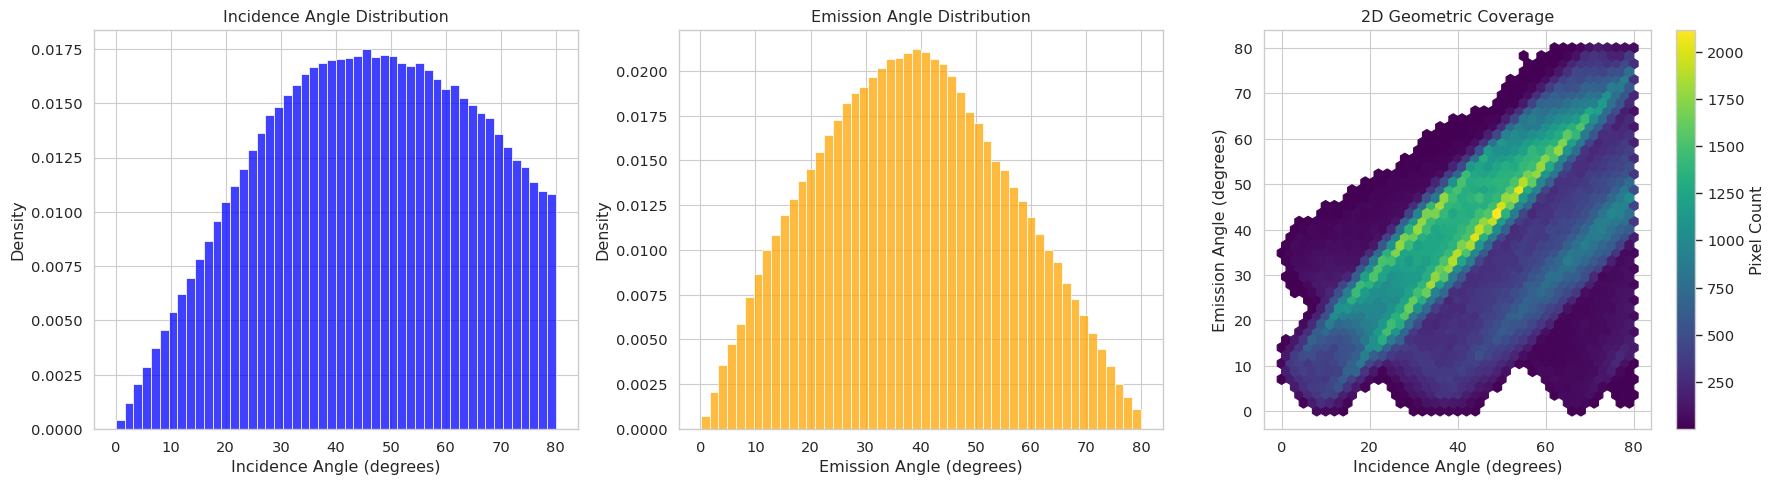

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Incidence Distribution
sns.histplot(df_rc['incidence'], bins=50, ax=axes[0], color='blue', stat='density')
axes[0].set_title('Incidence Angle Distribution')
axes[0].set_xlabel('Incidence Angle (degrees)')

# 2. Emission Distribution
sns.histplot(df_rc['emission'], bins=50, ax=axes[1], color='orange', stat='density')
axes[1].set_title('Emission Angle Distribution')
axes[1].set_xlabel('Emission Angle (degrees)')

# 3. 2D Phase Space Coverage
hb = axes[2].hexbin(df_rc['incidence'], df_rc['emission'], gridsize=40, cmap='viridis', mincnt=1)
axes[2].set_title('2D Geometric Coverage')
axes[2].set_xlabel('Incidence Angle (degrees)')
axes[2].set_ylabel('Emission Angle (degrees)')
cb = fig.colorbar(hb, ax=axes[2], label='Pixel Count')

plt.tight_layout()
plt.show()

I/F Mean:   0.1149
I/F Median: 0.1290
I/F Skew:   -0.5294 (Positive = Right-tailed)
----------------------------------------


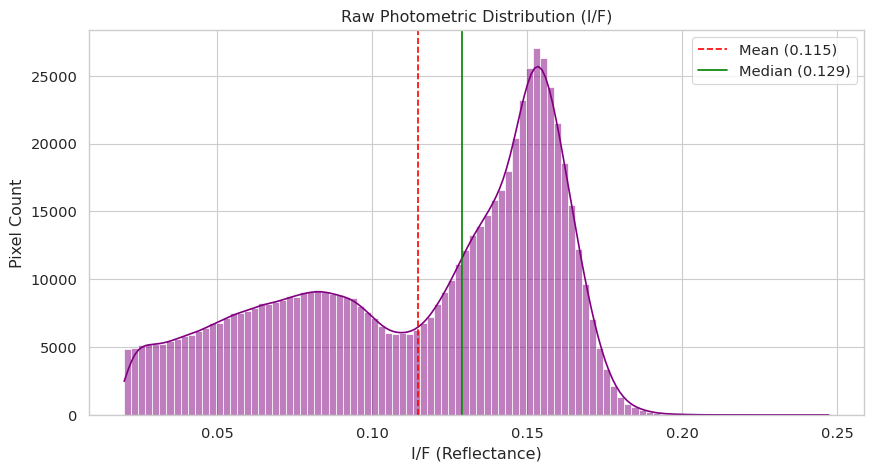

In [26]:
# Calculate Summary Statistics
iof_mean = df_rc['iof'].mean()
iof_median = df_rc['iof'].median()
iof_skew = skew(df_rc['iof'].dropna())

print(f"I/F Mean:   {iof_mean:.4f}")
print(f"I/F Median: {iof_median:.4f}")
print(f"I/F Skew:   {iof_skew:.4f} (Positive = Right-tailed)")
print("-" * 40)

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_rc['iof'], bins=100, kde=True, color='purple')
plt.axvline(iof_mean, color='red', linestyle='--', label=f'Mean ({iof_mean:.3f})')
plt.axvline(iof_median, color='green', linestyle='-', label=f'Median ({iof_median:.3f})')

plt.title('Raw Photometric Distribution (I/F)')
plt.xlabel('I/F (Reflectance)')
plt.ylabel('Pixel Count')
plt.legend()
plt.show()

Pearson Correlation (r): 0.4886
----------------------------------------


/tmp/ipykernel_52730/2016604632.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


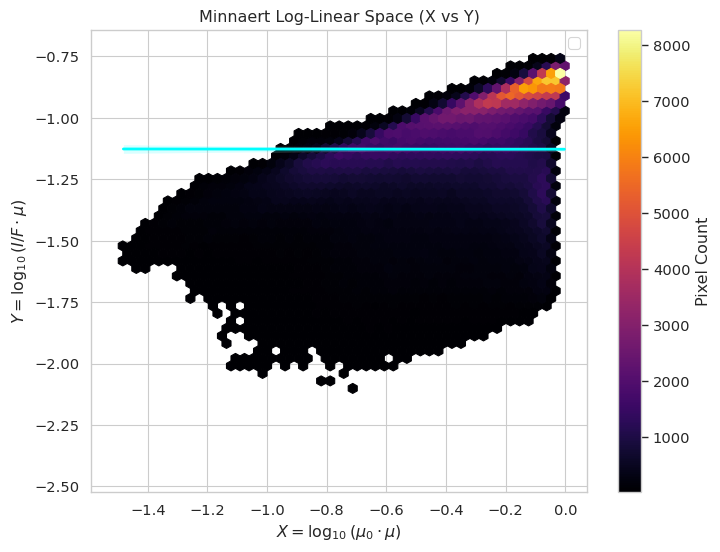

In [27]:
# Calculate Pearson Correlation
r_val, p_val = pearsonr(df_rc['x_minnaert'], df_rc['y_minnaert'])

print(f"Pearson Correlation (r): {r_val:.4f}")
print("-" * 40)

# Plot the 2D Density of the flattened space
plt.figure(figsize=(8, 6))
hb = plt.hexbin(df_rc['x_minnaert'], df_rc['y_minnaert'], gridsize=50, cmap='inferno', mincnt=10)

# Add a simple regression line for visual proof of the trend
sns.regplot(x=df_rc['x_minnaert'].sample(10000), y=df_rc['y_minnaert'].sample(10000), 
            scatter=False, color='cyan', line_kws={"linewidth": 2, "label": "Global Linear Trend"})

plt.title('Minnaert Log-Linear Space (X vs Y)')
plt.xlabel(r'$X = \log_{10}(\mu_0 \cdot \mu)$')
plt.ylabel(r'$Y = \log_{10}(I/F \cdot \mu)$')
plt.colorbar(hb, label='Pixel Count')
plt.legend()
plt.show()

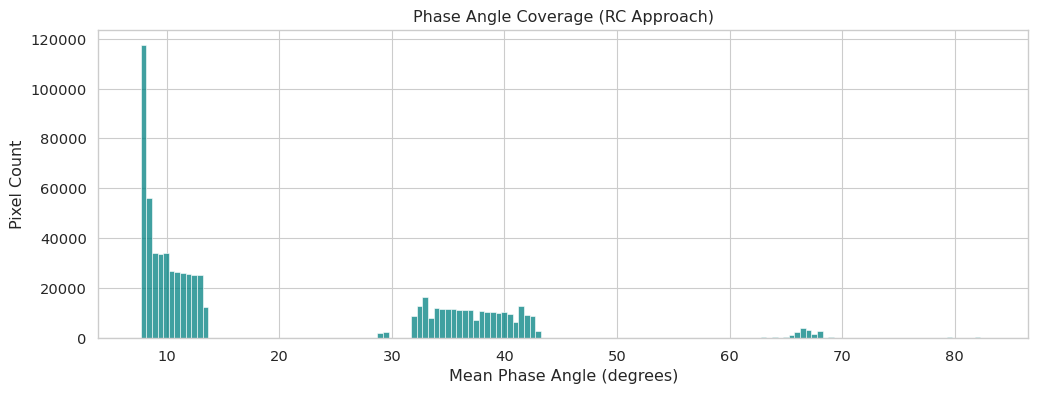

Sample Pixel Counts per 2-Degree Phase Bin:
mean_phase
(10, 12]    105620
(12, 14]     75793
(28, 30]      4525
(30, 32]      4263
(32, 34]     49919
(34, 36]     46714
(36, 38]     40201
(38, 40]     37992
(40, 42]     41934
(42, 44]     14724
dtype: int64


In [28]:
plt.figure(figsize=(12, 4))

# Plot Phase Angle with fine bins (0.5 degrees)
sns.histplot(df_rc['mean_phase'], binwidth=0.5, color='teal')

plt.title('Phase Angle Coverage (RC Approach)')
plt.xlabel('Mean Phase Angle (degrees)')
plt.ylabel('Pixel Count')
plt.show()

# Show exact counts for a few critical 2-degree slices
bins = pd.cut(df_rc['mean_phase'], bins=np.arange(10, 80, 2))
bin_counts = df_rc.groupby(bins, observed=False).size()

print("Sample Pixel Counts per 2-Degree Phase Bin:")
print(bin_counts[bin_counts > 0].head(10))

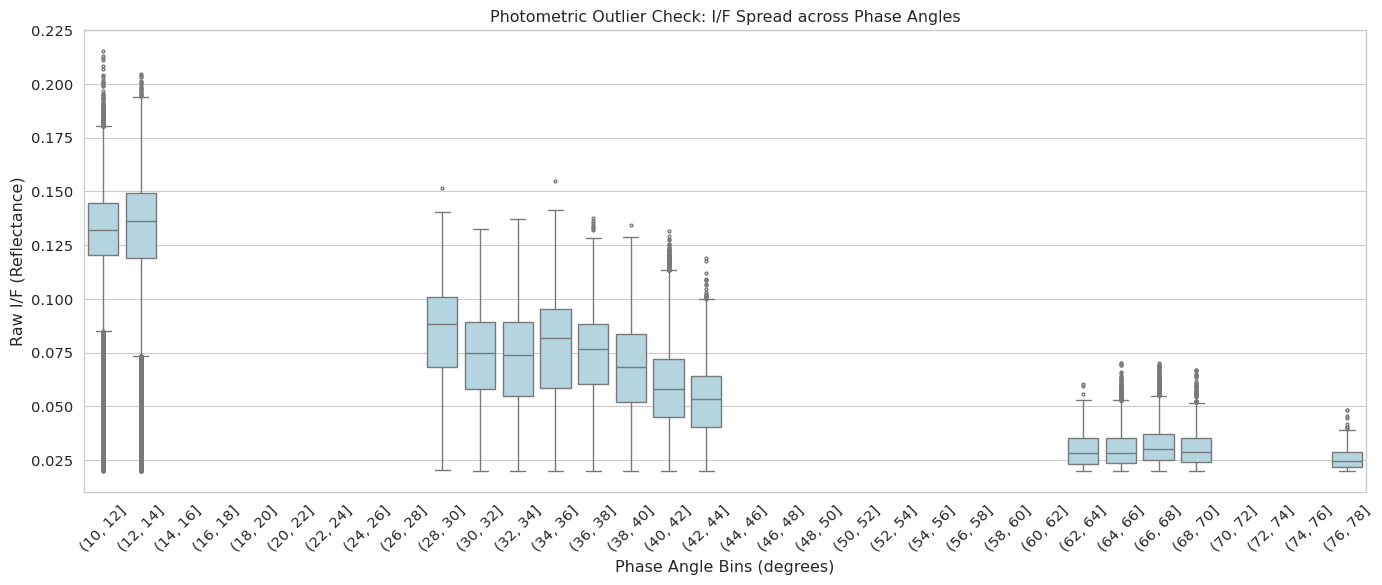

In [29]:
# Create 2-degree bins for the x-axis
df_rc['phase_bin'] = pd.cut(df_rc['mean_phase'], bins=np.arange(10, 80, 2))

plt.figure(figsize=(14, 6))
# Draw the boxplot to hunt for outliers
sns.boxplot(x='phase_bin', y='iof', data=df_rc, color='lightblue', fliersize=2)

plt.title('Photometric Outlier Check: I/F Spread across Phase Angles')
plt.xlabel('Phase Angle Bins (degrees)')
plt.ylabel('Raw I/F (Reflectance)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Global Correlation : 0.4886
Local Correlation (10-12 deg slice): 0.7686


/tmp/ipykernel_52730/2528611651.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


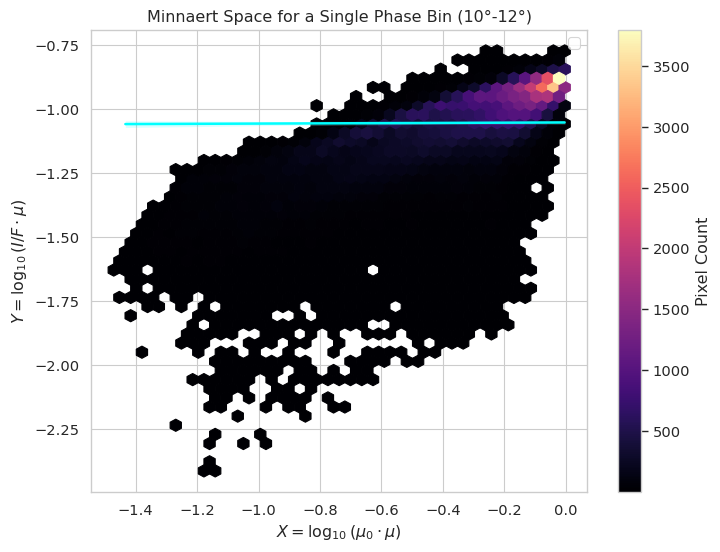

In [30]:


# Isolate the data for just one slice
slice_mask = (df_rc['mean_phase'] > 10) & (df_rc['mean_phase'] <= 12)
df_slice = df_rc[slice_mask]

# Calculate the local correlation
r_val_local, _ = pearsonr(df_slice['x_minnaert'], df_slice['y_minnaert'])

print(f"Global Correlation : {r_val:.4f}")
print(f"Local Correlation (10-12 deg slice): {r_val_local:.4f}")

# Plot the single slice to prove it's a line
plt.figure(figsize=(8, 6))
plt.hexbin(df_slice['x_minnaert'], df_slice['y_minnaert'], gridsize=40, cmap='magma', mincnt=1)
sns.regplot(x=df_slice['x_minnaert'].sample(10000), y=df_slice['y_minnaert'].sample(10000), 
            scatter=False, color='cyan', line_kws={"label": f"Local Fit (r = {r_val_local:.2f})"})

plt.title('Minnaert Space for a Single Phase Bin (10°-12°)')
plt.xlabel(r'$X = \log_{10}(\mu_0 \cdot \mu)$')
plt.ylabel(r'$Y = \log_{10}(I/F \cdot \mu)$')
plt.colorbar(label='Pixel Count')
plt.legend()
plt.show()

## Local Minnaert Fits

In [17]:
# Phase Bins (2-degree slices from 10 to 80 degrees)

bins = np.arange(10, 82, 5)
df_rc['phase_bin'] = pd.cut(df_rc['mean_phase'], bins=bins) # create categorical bins for phase angles

print(bins)

display(df_rc[['mean_phase', 'phase_bin']])

[10 15 20 25 30 35 40 45 50 55 60 65 70 75 80]


,mean_phase,phase_bin
0,28.922753,"(25, 30]"
1,28.922753,"(25, 30]"
2,28.922753,"(25, 30]"
3,28.922753,"(25, 30]"
4,28.922753,"(25, 30]"
...,...,...
700770,63.012024,"(60, 65]"
700771,63.012024,"(60, 65]"
700772,63.012024,"(60, 65]"
700773,63.012024,"(60, 65]"


In [18]:

extracted_params = []

# Loop through each bin and run the regression

for bin_name, group in df_rc.groupby('phase_bin', observed=False):
    
    if len(group) > 1000: # Only fit bins with sufficient data points

        # Run Linear Least-Squares Regression
        
        slope, intercept, r_value, p_value, std_err = linregress(
            group['x_minnaert'], group['y_minnaert']
        ) # X = log10(mu0 * mu), Y = log10(I/F * mu)
        
        # Extract the Physics
        mean_alpha = group['mean_phase'].mean()
        k_local = slope                  # Slope = k
        A_local = 10 ** intercept        # Antilog of intercept = Albedo
        
        # Store results
        extracted_params.append({
            'mean_phase': mean_alpha,
            'k': k_local,
            'k_err': std_err,
            'A': A_local,
            'r_squared': r_value**2,
            'n_pixels': len(group)
        })


df_minnaert_local = pd.DataFrame(extracted_params)

print(f"Successfully extracted parameters for {len(df_minnaert_local)} phase slices.")
print("\nPreview of extracted k and A parameters:")
display(df_minnaert_local)

Successfully extracted parameters for 6 phase slices.

Preview of extracted k and A parameters:


,mean_phase,k,k_err,A,r_squared,n_pixels
0,11.671346,0.439912,0.000941,0.123100,0.546594,181413
1,29.219563,0.104796,0.010063,0.068067,0.023418,4525
2,33.358377,0.017041,0.002576,0.053989,0.000564,77538
3,37.413563,0.036731,0.002279,0.056179,0.002551,101551
4,41.393903,-0.030694,0.002871,0.043198,0.002014,56658
5,66.915237,0.160979,0.006344,0.032282,0.040061,15433


Retained 1 highly stable low-phase bins out of 6 total.
----------------------------------------
EXTRACTED GLOBAL BASELINE PARAMETERS:
k_0 (Zero-Phase Limb Darkening): nan  <-- Target: ~0.53
A_0 (Zero-Phase Normal Albedo):  nan
Beta (Phase Slope mag/deg):      nan
----------------------------------------


/tmp/ipykernel_52730/393881731.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  k_slope, k_intercept, _, _, _ = linregress(df_clean['mean_phase'], df_clean['k'])
/tmp/ipykernel_52730/393881731.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  A_slope, A_intercept, _, _, _ = linregress(df_clean['mean_phase'], log_A)


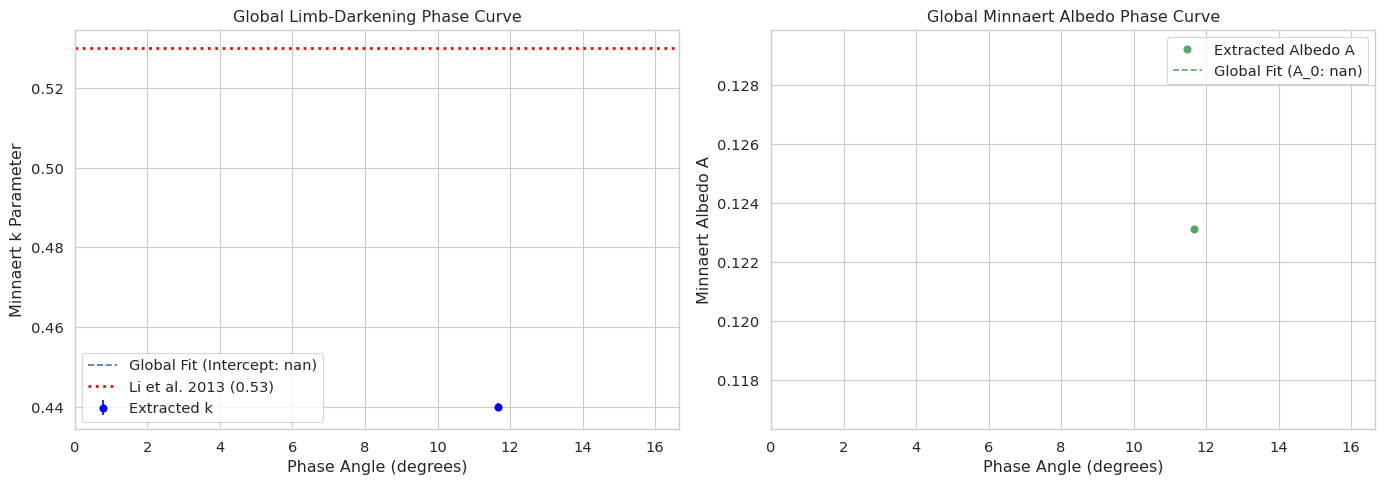

In [19]:


# ---------------------------------------------------------
# 1. The Scientific Filter (Rejecting the Noise)
# ---------------------------------------------------------
# We only trust bins where the correlation was strong enough to prove the physics.
# An r_squared > 0.1 on raw pixel data guarantees a geometric lever arm.
df_clean = df_minnaert_local[df_minnaert_local['r_squared'] > 0.1].copy()

print(f"Retained {len(df_clean)} highly stable low-phase bins out of {len(df_minnaert_local)} total.")

# ---------------------------------------------------------
# 2. Phase 2 Global Fits
# ---------------------------------------------------------
# Fit A: Extrapolate baseline Limb-Darkening (k_0)
k_slope, k_intercept, _, _, _ = linregress(df_clean['mean_phase'], df_clean['k'])
k_0 = k_intercept  # This is the ultimate prize

# Fit B: Extrapolate normal Albedo (A_0) using log-linear decay
log_A = np.log10(df_clean['A'])
A_slope, A_intercept, _, _, _ = linregress(df_clean['mean_phase'], log_A)
A_0 = 10 ** A_intercept
beta = A_slope / -0.4  # Phase slope in mag/deg

print("-" * 40)
print("EXTRACTED GLOBAL BASELINE PARAMETERS:")
print(f"k_0 (Zero-Phase Limb Darkening): {k_0:.4f}  <-- Target: ~0.53")
print(f"A_0 (Zero-Phase Normal Albedo):  {A_0:.4f}")
print(f"Beta (Phase Slope mag/deg):      {beta:.4f}")
print("-" * 40)

# ---------------------------------------------------------
# 3. Visualization
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.linspace(0, df_clean['mean_phase'].max() + 5, 100)

# Plot 1: Limb Darkening (k)
axes[0].errorbar(df_clean['mean_phase'], df_clean['k'], yerr=df_clean['k_err'], 
                 fmt='o', color='blue', label='Extracted k')
axes[0].plot(x_line, k_intercept + k_slope * x_line, 'b--', label=f'Global Fit (Intercept: {k_0:.2f})')
axes[0].axhline(0.53, color='red', linestyle=':', linewidth=2, label='Li et al. 2013 (0.53)')

axes[0].set_title('Global Limb-Darkening Phase Curve')
axes[0].set_xlabel('Phase Angle (degrees)')
axes[0].set_ylabel('Minnaert k Parameter')
axes[0].set_xlim(0, max(x_line))
axes[0].legend()

# Plot 2: Albedo (A)
axes[1].plot(df_clean['mean_phase'], df_clean['A'], 'go', label='Extracted Albedo A')
axes[1].plot(x_line, 10**(A_intercept + A_slope * x_line), 'g--', label=f'Global Fit (A_0: {A_0:.2f})')

axes[1].set_title('Global Minnaert Albedo Phase Curve')
axes[1].set_xlabel('Phase Angle (degrees)')
axes[1].set_ylabel('Minnaert Albedo A')
axes[1].set_xlim(0, max(x_line))
axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
grid_size = 2.0  
df_rc['i_grid'] = np.floor(df_rc['incidence'] / grid_size) * grid_size
df_rc['e_grid'] = np.floor(df_rc['emission'] / grid_size) * grid_size
df_rc['alpha_grid'] = np.floor(df_rc['mean_phase'] / grid_size) * grid_size

display(df_rc.iloc[100:200])

df_grid = df_rc.groupby(['alpha_grid', 'i_grid', 'e_grid']).agg({
    'incidence': 'mean',
    'emission': 'mean',
    'mean_phase': 'mean',
    'iof': 'mean',
    'pixel_x': 'count' 
}).reset_index()
display(df_grid)


,image_id,pixel_x,pixel_y,iof,incidence,emission,phase,latitude,longitude,x_minnaert,y_minnaert,mean_phase,phase_bin,i_grid,e_grid,alpha_grid
100,FC21B0002677_11191001017F1E,497,508,0.091406,39.444134,21.786646,28.984228,-36.612141,-104.705475,-0.144429,-1.071209,28.922753,"(28, 30]",38.0,20.0,28.0
101,FC21B0002677_11191001017F1E,516,508,0.098914,50.844456,27.156527,28.882555,-45.266464,-121.241470,-0.250402,-1.055470,28.922753,"(28, 30]",50.0,26.0,28.0
102,FC21B0002677_11191001017F1E,534,509,0.090253,62.876541,37.254971,28.786232,-48.300617,-144.422928,-0.440236,-1.143652,28.922753,"(28, 30]",62.0,36.0,28.0
103,FC21B0002677_11191001017F1E,511,512,0.093948,48.800758,27.496105,28.909317,-40.636204,-118.852730,-0.233382,-1.079170,28.922753,"(28, 30]",48.0,26.0,28.0
104,FC21B0002677_11191001017F1E,466,514,0.029238,30.000170,37.997845,29.150126,-14.683887,-93.336342,-0.165925,-1.637503,28.922753,"(28, 30]",30.0,36.0,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,FC21B0002694_11191003659F1E,460,503,0.031713,20.346027,33.841656,29.234663,-15.588511,-114.019318,-0.108596,-1.579378,28.973136,"(28, 30]",20.0,32.0,28.0
196,FC21B0002694_11191003659F1E,541,506,0.106821,67.907379,41.232819,28.801208,-50.212109,175.924057,-0.548451,-1.095103,28.973136,"(28, 30]",66.0,40.0,28.0
197,FC21B0002694_11191003659F1E,477,508,0.057408,28.028215,24.892632,29.143686,-25.081911,-123.773247,-0.096525,-1.283372,28.973136,"(28, 30]",28.0,24.0,28.0
198,FC21B0002694_11191003659F1E,520,509,0.110402,53.811058,29.429285,28.913586,-45.748829,-156.223328,-0.288817,-1.017025,28.973136,"(28, 30]",52.0,28.0,28.0


,alpha_grid,i_grid,e_grid,incidence,emission,mean_phase,iof,pixel_x
0,6.0,0.0,6.0,1.390398,7.213237,7.809972,0.155288,53
1,6.0,0.0,8.0,1.204263,9.036564,7.804926,0.152982,74
2,6.0,0.0,10.0,1.875140,10.153545,7.840068,0.147240,6
3,6.0,2.0,2.0,3.968434,3.956220,7.744927,0.170372,1
4,6.0,2.0,4.0,3.248113,5.292779,7.792140,0.156182,70
...,...,...,...,...,...,...,...,...
9728,82.0,78.0,54.0,78.576309,55.088734,82.024979,0.021261,2
9729,82.0,78.0,62.0,79.554779,62.915531,82.024979,0.024985,1
9730,82.0,78.0,66.0,79.135925,66.555458,82.780460,0.023248,1
9731,82.0,78.0,72.0,79.027084,72.815079,82.567292,0.030038,2


In [42]:


# 3D Grid construction inspired by Li et al. (2013)

grid_size = 2.0  
df_rc['i_grid'] = np.floor(df_rc['incidence'] / grid_size) * grid_size
df_rc['e_grid'] = np.floor(df_rc['emission'] / grid_size) * grid_size
df_rc['alpha_grid'] = np.floor(df_rc['mean_phase'] / grid_size) * grid_size


# Smoothing Step

df_grid = df_rc.groupby(['alpha_grid', 'i_grid', 'e_grid']).agg({
    'incidence': 'mean',
    'emission': 'mean',
    'mean_phase': 'mean',
    'iof': 'mean',
    'pixel_x': 'count' 
}).reset_index()

df_grid.rename(columns={'pixel_x': 'n_pixels'}, inplace=True)


df_grid = df_grid[df_grid['n_pixels'] >= 5].copy() # Discard grid cubes that are mostly empty (statistical noise)

print(f"Compressed {len(df_rc):,} raw pixels into {len(df_grid):,} smoothed 3D cubes.")


# Recalculating Minnaert X and Y for the Smoothed Data

mu_0_smooth = np.cos(np.radians(df_grid['incidence']))
mu_smooth = np.cos(np.radians(df_grid['emission']))

df_grid['x_minnaert'] = np.log10(mu_0_smooth * mu_smooth)
df_grid['y_minnaert'] = np.log10(df_grid['iof'] * mu_smooth)






Compressed 700,775 raw pixels into 7,589 smoothed 3D cubes.


In [ ]:
# Regressions on the Smoothed 3D Grid Data

extracted_params = []


for alpha_val, group in df_grid.groupby('alpha_grid', observed=False):
    
    if len(group) > 20: 
        slope, intercept, r_value, p_value, std_err = linregress(
            group['x_minnaert'], group['y_minnaert']
        )
        extracted_params.append({
            'mean_phase': group['mean_phase'].mean(),
            'k': slope,
            'k_err': std_err,
            'A': 10 ** intercept,
            'r_squared': r_value**2,
            'n_cubes': len(group)
        })

df_minnaert_smooth = pd.DataFrame(extracted_params)


#df_clean_smooth = df_minnaert_smooth[df_minnaert_smooth['r_squared'] > 0.1].copy()

valid_mask = (
    (df_minnaert_smooth['r_squared'] > 0.4) & 
    (df_minnaert_smooth['k'] > 0.35) & 
    (df_minnaert_smooth['mean_phase'] < 60.0)
)
df_clean_smooth = df_minnaert_smooth[valid_mask].copy()

print(f"Purged unphysical terminator data. Retained {len(df_clean_smooth)} pristine phase bins.")



# Extrapolate k_0
k_slope, k_intercept, _, _, _ = linregress(df_clean_smooth['mean_phase'], df_clean_smooth['k'])
k_0_smooth = k_intercept

# Extrapolate A_0
log_A = np.log10(df_clean_smooth['A'])
A_slope, A_intercept, _, _, _ = linregress(df_clean_smooth['mean_phase'], log_A)
A_0_smooth = 10 ** A_intercept
beta_smooth = A_slope / -0.4



print("-" * 50)
print("EXTRACTED GLOBAL BASELINE PARAMETERS (Smoothed 3D Grid):")
print(f"k_0 (Zero-Phase Limb Darkening): {k_0_smooth:.4f}  <-- Target: ~0.53")
print(f"A_0 (Zero-Phase Normal Albedo):  {A_0_smooth:.4f} ")
print(f"Beta (Phase Slope mag/deg):      {beta_smooth:.4f}")
print("-" * 50)

Purged unphysical terminator data. Retained 4 pristine phase bins.
--------------------------------------------------
EXTRACTED GLOBAL BASELINE PARAMETERS (Smoothed 3D Grid):
k_0 (Zero-Phase Limb Darkening): 0.5813  <-- Target: ~0.53
A_0 (Zero-Phase Normal Albedo):  0.2111 
Beta (Phase Slope mag/deg):      0.0451
--------------------------------------------------


: 

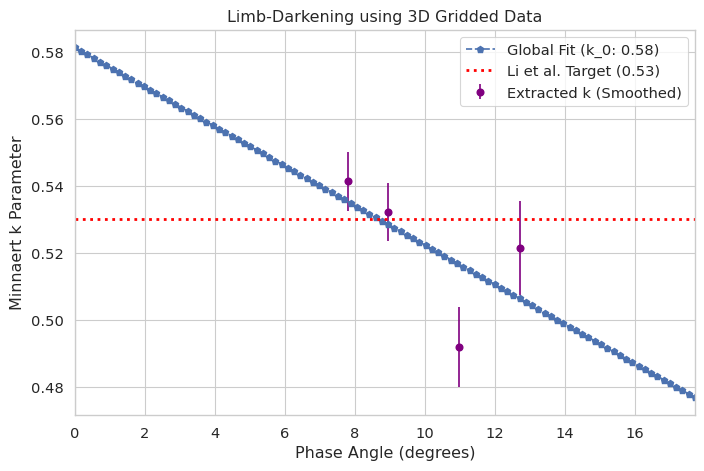

In [55]:

plt.figure(figsize=(8,5))
x_line = np.linspace(0, df_clean_smooth['mean_phase'].max() + 5, 100)
plt.errorbar(df_clean_smooth['mean_phase'], df_clean_smooth['k'], yerr=df_clean_smooth['k_err'], 
             fmt='o', color='purple', label='Extracted k (Smoothed)')
plt.plot(x_line, k_intercept + k_slope * x_line, 'p--', label=f'Global Fit (k_0: {k_0_smooth:.2f})')
plt.axhline(0.53, color='red', linestyle=':', linewidth=2, label='Li et al. Target (0.53)')
plt.title('Limb-Darkening using 3D Gridded Data')
plt.xlabel('Phase Angle (degrees)')
plt.ylabel('Minnaert k Parameter')
plt.xlim(0, max(x_line))
plt.legend()
plt.show()

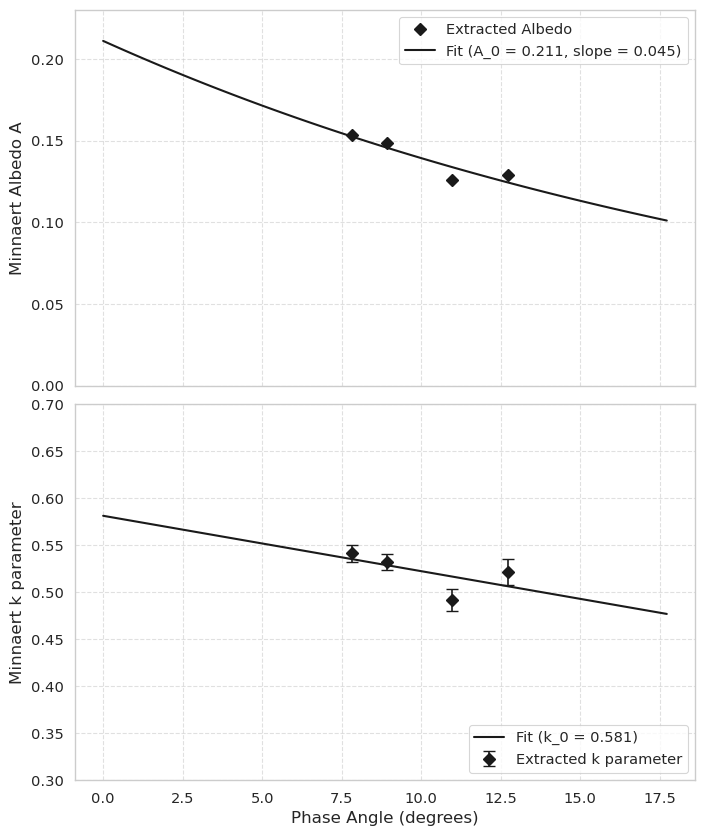

In [56]:
x_phase = np.linspace(0, df_clean_smooth['mean_phase'].max() + 5, 100)

# Calculate the continuous model fits
A_fit = A_0_smooth * 10 ** (-0.4 * beta_smooth * x_phase)
k_fit = k_0_smooth + k_slope * x_phase

# Set up the publication-style 2-panel plot
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
fig.subplots_adjust(hspace=0.05) # Squeeze panels together like the paper

# ---------------------------------------------------------
# Panel (a): Minnaert Albedo (LINEAR SCALE)
# ---------------------------------------------------------
axes[0].plot(df_clean_smooth['mean_phase'], df_clean_smooth['A'], 'kD', markersize=6, label='Extracted Albedo')
axes[0].plot(x_phase, A_fit, 'k-', linewidth=1.5, label=f'Fit (A_0 = {A_0_smooth:.3f}, slope = {beta_smooth:.3f})')

axes[0].set_ylabel('Minnaert Albedo A', fontsize=12)
axes[0].set_ylim(0.0, df_clean_smooth['A'].max() * 1.5) # Ground the y-axis at 0
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='upper right')

# ---------------------------------------------------------
# Panel (b): Minnaert k Parameter
# ---------------------------------------------------------
axes[1].errorbar(df_clean_smooth['mean_phase'], df_clean_smooth['k'], yerr=df_clean_smooth['k_err'], 
                 fmt='kD', markersize=6, capsize=4, label='Extracted k parameter')
axes[1].plot(x_phase, k_fit, 'k-', linewidth=1.5, label=f'Fit (k_0 = {k_0_smooth:.3f})')

axes[1].set_xlabel('Phase Angle (degrees)', fontsize=12)
axes[1].set_ylabel('Minnaert k parameter', fontsize=12)
axes[1].set_ylim(0.3, 0.7) # Standardize the Y-axis to match the paper
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='lower right')

plt.show()

Total Model RMS Error: 17.80%
Linear Correlation (r): -0.098


/tmp/ipykernel_52730/1021008966.py:69: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


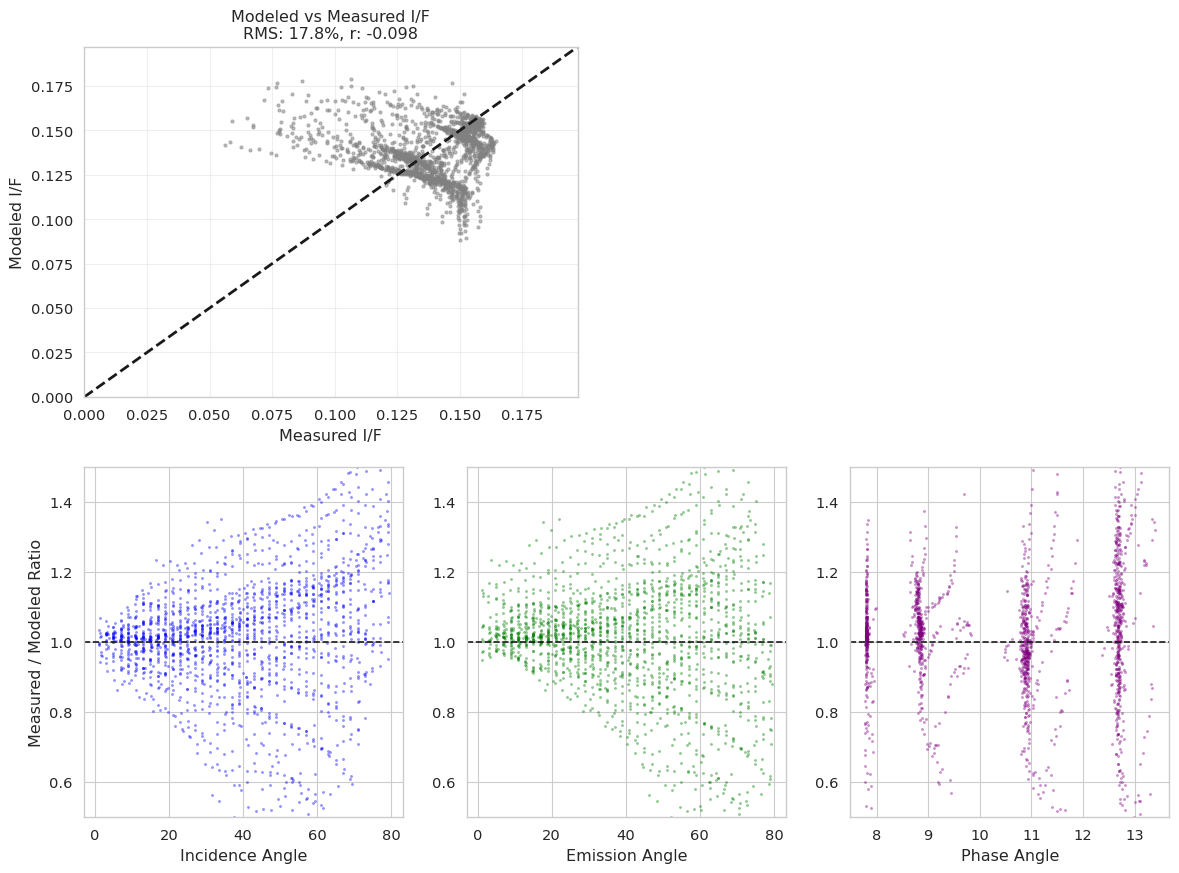

In [57]:
def calc_minnaert_iof(inc, emi, alpha, k0, k_slope, A0, beta):
    mu_0 = np.cos(np.radians(inc))
    mu = np.cos(np.radians(emi))
    
    # Calculate local k and A for the specific phase angle of the pixel
    k_local = k0 + k_slope * alpha
    A_local = A0 * 10 ** (-0.4 * beta * alpha)
    
    return A_local * (mu_0 ** k_local) * (mu ** (k_local - 1.0))

# 2. Calculate the predicted I/F for our valid smoothed cubes
# We strictly test this on the cubes that fell within our clean phase bins
# Map cleaned smooth-phase means to the gridded alpha bins and select matching cubes
alpha_vals = (np.floor(df_clean_smooth['mean_phase'] / grid_size) * grid_size).unique()
df_test = df_grid[df_grid['alpha_grid'].isin(alpha_vals)].copy()

df_test['model_iof'] = calc_minnaert_iof(
    df_test['incidence'], 
    df_test['emission'], 
    df_test['mean_phase'], 
    k_0_smooth, k_slope, A_0_smooth, beta_smooth
)

# Calculate Ratio and RMS
df_test['ratio'] = df_test['iof'] / df_test['model_iof']
rms_error = np.sqrt(np.mean((df_test['iof'] - df_test['model_iof'])**2))
rms_percent = (rms_error / df_test['iof'].mean()) * 100
r_val, _ = pearsonr(df_test['iof'], df_test['model_iof'])

print(f"Total Model RMS Error: {rms_percent:.2f}%")
print(f"Linear Correlation (r): {r_val:.3f}")

# 3. Setup the 4-panel diagnostic plot (Combining Panel A and Panel B logic)
fig = plt.figure(figsize=(14, 10))

# Panel (a): Modeled vs Measured I/F
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(df_test['iof'], df_test['model_iof'], s=5, color='gray', alpha=0.5)
ax1.plot([0, 0.3], [0, 0.3], 'k--', linewidth=2) # 1:1 Reference Line
ax1.set_title(f'Modeled vs Measured I/F\nRMS: {rms_percent:.1f}%, r: {r_val:.3f}')
ax1.set_xlabel('Measured I/F')
ax1.set_ylabel('Modeled I/F')
ax1.set_xlim(0, max(df_test['iof'].max(), df_test['model_iof'].max()) * 1.1)
ax1.set_ylim(0, max(df_test['iof'].max(), df_test['model_iof'].max()) * 1.1)
ax1.grid(True, alpha=0.3)

# Panel (b1): Ratio vs Incidence
ax2 = plt.subplot(2, 3, 4)
ax2.scatter(df_test['incidence'], df_test['ratio'], s=2, color='blue', alpha=0.3)
ax2.axhline(1.0, color='k', linestyle='--')
ax2.set_xlabel('Incidence Angle')
ax2.set_ylabel('Measured / Modeled Ratio')
ax2.set_ylim(0.5, 1.5)

# Panel (b2): Ratio vs Emission
ax3 = plt.subplot(2, 3, 5)
ax3.scatter(df_test['emission'], df_test['ratio'], s=2, color='green', alpha=0.3)
ax3.axhline(1.0, color='k', linestyle='--')
ax3.set_xlabel('Emission Angle')
ax3.set_ylim(0.5, 1.5)

# Panel (b3): Ratio vs Phase
ax4 = plt.subplot(2, 3, 6)
ax4.scatter(df_test['mean_phase'], df_test['ratio'], s=2, color='purple', alpha=0.3)
ax4.axhline(1.0, color='k', linestyle='--')
ax4.set_xlabel('Phase Angle')
ax4.set_ylim(0.5, 1.5)

plt.tight_layout()
plt.show()



In [7]:
# Set up paths and load phase-curve data for all phases

project_root = Path.cwd().resolve()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent
data_root = project_root / "data" / "05_aggregated"
csv_files = sorted(data_root.glob("*_phase_curve.csv"))
phase_dfs = {}
for path in csv_files:
    phase = path.stem.replace("_phase_curve", "").lower()
    phase_dfs[phase] = pd.read_csv(path)

# Ensure phase DataFrames exist
df_rc = phase_dfs.get("rc", pd.DataFrame()).copy()
df_survey = phase_dfs.get("survey", pd.DataFrame()).copy()
df_hamo = phase_dfs.get("hamo", pd.DataFrame()).copy()
df_lamo = phase_dfs.get("lamo", pd.DataFrame()).copy()

# Apply incidence quality filter: 
def apply_incidence_filter(df, phase_name):
    if df is None or df.empty:
        return df
    max_incidence = 80.0 if phase_name == "rc" else 70.0 # Allow higher incidence angles for RC phase due to its unique geometry
    return df[(df["mean_incidence"] <= max_incidence) & (df["median_iof"] > 0.01)].dropna().copy()

rc_f = apply_incidence_filter(df_rc, "rc")
survey_f = apply_incidence_filter(df_survey, "survey")
hamo_f = apply_incidence_filter(df_hamo, "hamo")
lamo_f = apply_incidence_filter(df_lamo, "lamo")


print("RC, Survey, HAMO, and LAMO phase-curve data (first 5 rows each):\n")
display(df_rc.head())
display(df_survey.head())    
display(df_hamo.head())
display(df_lamo.head())

print("\nAfter applying incidence quality filter (mean_incidence <= 60.0 degrees) and (median_iof > 0.01):\n")

display(rc_f.head())
display(survey_f.head())    
display(hamo_f.head())
display(lamo_f.head())


# Extract n_pixels array from each phase DataFrame
    
rc_n_pixels = rc_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in rc_f.columns else None
survey_n_pixels = survey_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in survey_f.columns else None
hamo_n_pixels = hamo_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in hamo_f.columns else None
lamo_n_pixels = lamo_f["n_pixels"].to_numpy(dtype=float) if "n_pixels" in lamo_f.columns else None


n_pixels_arrays = [rc_n_pixels, survey_n_pixels, hamo_n_pixels, lamo_n_pixels]
print("n_pixels_arrays:", n_pixels_arrays)

# Print the recovered mean phase angles to verify the fix
print("RECOVERED MEAN PHASE ANGLES (Pixel-Weighted):")
for name, df in zip(["RC", "Survey", "HAMO", "LAMO"], [rc_f, survey_f, hamo_f, lamo_f]):
    if df is not None and not df.empty:
        mean_phase = np.average(df['mean_phase'], weights=df['n_pixels'])
        print(f"{name}: {mean_phase:.2f} deg")

RC, Survey, HAMO, and LAMO phase-curve data (first 5 rows each):



,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,5.0,176610,0.153111,0.148464,0.157871,71.626347,66.758334,5.114231,0.094291
1,5.5,666541,0.156039,0.150362,0.162856,63.232285,58.376821,5.530364,0.141122
2,6.0,1161459,0.158313,0.152694,0.164295,56.575414,51.795269,6.018118,0.143254
3,6.5,1672728,0.158304,0.152456,0.165015,51.476546,46.875979,6.512820,0.143740
4,7.0,2181162,0.157746,0.151293,0.165099,47.177785,42.928023,7.009494,0.144009


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,8.0,163084,0.127764,0.121919,0.132857,44.651761,37.681212,8.313530,0.127900
1,9.0,874208,0.129695,0.123402,0.136492,41.333485,34.328091,9.054928,0.283673
2,10.0,1756912,0.133439,0.126205,0.142761,38.814568,31.536061,10.069156,0.279871
3,11.0,2833907,0.134607,0.126649,0.142374,35.978741,28.967223,11.027184,0.286223
4,12.0,3634362,0.134512,0.124658,0.143150,32.712833,27.238264,12.016458,0.289264


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,19.0,42045,0.110105,0.106279,0.114559,51.648175,33.960879,19.446580,0.039433
1,20.0,2598714,0.107980,0.103248,0.113012,50.349700,32.887181,20.128212,0.257699
2,21.0,6324931,0.112733,0.107491,0.117502,47.310793,29.454187,21.044422,0.283905
3,22.0,7677986,0.112669,0.107517,0.118399,41.535133,23.917346,21.999951,0.288678
4,23.0,7678365,0.113152,0.106977,0.120662,34.173785,18.487663,23.000286,0.288829


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,27.0,1893773,0.096468,0.088802,0.103189,39.854174,22.729714,27.118177,0.243559
1,28.0,3403287,0.093369,0.085087,0.102391,37.828540,21.645932,28.024512,0.286757
2,29.0,4281461,0.092531,0.084355,0.101292,36.102878,20.928407,29.014964,0.288129
3,30.0,5008024,0.092620,0.084336,0.101277,34.603879,20.573412,30.010433,0.288535
4,31.0,5640772,0.091657,0.084025,0.099982,33.260396,20.540697,31.009144,0.288751


...

,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,5.0,176610,0.153111,0.148464,0.157871,71.626347,66.758334,5.114231,0.094291
1,5.5,666541,0.156039,0.150362,0.162856,63.232285,58.376821,5.530364,0.141122
2,6.0,1161459,0.158313,0.152694,0.164295,56.575414,51.795269,6.018118,0.143254
3,6.5,1672728,0.158304,0.152456,0.165015,51.476546,46.875979,6.512820,0.143740
4,7.0,2181162,0.157746,0.151293,0.165099,47.177785,42.928023,7.009494,0.144009


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,8.0,163084,0.127764,0.121919,0.132857,44.651761,37.681212,8.313530,0.127900
1,9.0,874208,0.129695,0.123402,0.136492,41.333485,34.328091,9.054928,0.283673
2,10.0,1756912,0.133439,0.126205,0.142761,38.814568,31.536061,10.069156,0.279871
3,11.0,2833907,0.134607,0.126649,0.142374,35.978741,28.967223,11.027184,0.286223
4,12.0,3634362,0.134512,0.124658,0.143150,32.712833,27.238264,12.016458,0.289264


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,19.0,42045,0.110105,0.106279,0.114559,51.648175,33.960879,19.446580,0.039433
1,20.0,2598714,0.107980,0.103248,0.113012,50.349700,32.887181,20.128212,0.257699
2,21.0,6324931,0.112733,0.107491,0.117502,47.310793,29.454187,21.044422,0.283905
3,22.0,7677986,0.112669,0.107517,0.118399,41.535133,23.917346,21.999951,0.288678
4,23.0,7678365,0.113152,0.106977,0.120662,34.173785,18.487663,23.000286,0.288829


,phase_bin_deg,n_pixels,median_iof,iof_q25,iof_q75,mean_incidence,mean_emission,mean_phase,stddev_phase
0,27.0,1893773,0.096468,0.088802,0.103189,39.854174,22.729714,27.118177,0.243559
1,28.0,3403287,0.093369,0.085087,0.102391,37.828540,21.645932,28.024512,0.286757
2,29.0,4281461,0.092531,0.084355,0.101292,36.102878,20.928407,29.014964,0.288129
3,30.0,5008024,0.092620,0.084336,0.101277,34.603879,20.573412,30.010433,0.288535
4,31.0,5640772,0.091657,0.084025,0.099982,33.260396,20.540697,31.009144,0.288751


n_pixels_arrays: [array([ 176610.,  666541., 1161459., 1672728., 2181162., 2659699.,
       3092602., 3466045., 3765098., 3952088., 3998382., 3594699.,
       3169919., 2895271., 2591638., 2264496., 1916533., 1551323.,
       1180868.,  831513.,  763866., 1780890., 2830039., 3619164.,
       3733560., 3700865., 3662191., 3630765., 3599324., 3624391.,
       3727469., 3346726.,  806425., 1805125.]), array([  163084.,   874208.,  1756912.,  2833907.,  3634362.,  4555348.,
        5715947.,  6932308.,  7508790., 11457801., 14090010., 14155328.,
       12135982.,  9712427.,  9419541.,  9583059.,  9944809., 10459507.,
       11423299., 11750041., 12636785., 13353487., 13203763., 13554362.,
       12845104., 12225080., 12224699., 12195417., 11779390., 11699397.,
       11771869., 11201411., 11616249., 12424169., 12308925., 12728543.,
       12404551., 11576523., 11563653., 11786709., 11357469., 11665832.,
       12244648., 12628102., 13016027., 13024415., 12398666., 12449830.,
       1259426

In [ ]:
help(MinnaertModel)
model_instance = MinnaertModel
model_instance.

Help on class MinnaertModel in module photometry.models.baselines:

class MinnaertModel(photometry.models.base.BasePhotometricModel)
 |  MinnaertModel(model_name: 'str' = 'minnaert', parameters: 'dict[str, float]' = <factory>, metadata: 'dict[str, Any]' = <factory>, backend: 'Backend' = <Backend.AUTO: 'auto'>) -> None
 |  
 |  Empirical Minnaert disk-function model.
 |  
 |  Method resolution order:
 |      MinnaertModel
 |      photometry.models.base.BasePhotometricModel
 |      abc.ABC
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, model_name: 'str' = 'minnaert', parameters: 'dict[str, float]' = <factory>, metadata: 'dict[str, Any]' = <factory>, backend: 'Backend' = <Backend.AUTO: 'auto'>) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __post_init__(self) -> 'None'
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  parameter_bounds(self) -> 'dict[

<function photometry.models.baselines.MinnaertModel.parameter_names(self) -> 'list[str]'>

In [11]:

phases = [("RC", rc_f), ("Survey", survey_f), ("HAMO", hamo_f), ("LAMO", lamo_f)]
fitter = LeastSquaresFitter()


results = {}
for phase_name, df_phase in phases:
    if df_phase is None or df_phase.empty:
        print(f"{phase_name}: no data after 60° incidence filter")
        continue

    incidence_rad = np.deg2rad(df_phase["mean_incidence"].to_numpy(dtype=float))
    emission_rad = np.deg2rad(df_phase["mean_emission"].to_numpy(dtype=float))
    phase_rad = np.deg2rad(df_phase["mean_phase"].to_numpy(dtype=float))

    geom_batch = GeometryBatch(
        incidence=incidence_rad,
        emission=emission_rad,
        phase=phase_rad,
    )

    observed = df_phase["median_iof"].to_numpy(dtype=float) # observed I/F values
    n_pixels = df_phase["n_pixels"].to_numpy(dtype=float) if "n_pixels" in df_phase.columns else None # weights based on n_pixels if available, else None for unweighted fit 
    #weights = np.sqrt(n_pixels)/(df_phase['iof_q75'] - df_phase['iof_q25']).replace(0, np.nan).fillna(df_phase['median_iof']*0.1) # avoid division by zero; will result in NaN weights for those points which are effectively ignored in the fit
    
    weights_series = np.sqrt(n_pixels) / (df_phase['iof_q75'] - df_phase['iof_q25']).replace(0, np.nan).fillna(df_phase['median_iof']*0.1)
    weights = weights_series.to_numpy(dtype=float) # safety cast

    model_instance = MinnaertModel()
    fit_result = fitter.fit(model_instance, geom_batch, observed, weights=weights) # Use unweighted fit for now; can switch to weights=weights if desired

    # Extract fitted parameters and statistics

    fitted_params = fit_result.fitted_parameters
    parameter_errors = fit_result.metadata.get("parameter_errors", {})

   

    results[phase_name] = {
        "parameters": fitted_params,
        "parameter_errors": parameter_errors,
        "n_bins": int(len(df_phase)),
        "reduced_chi_square": float(fit_result.metadata.get("reduced_chi_square")) if fit_result.metadata.get("reduced_chi_square") is not None else None,
    }



    param_str = ", ".join([f"{k} = {v:.4f}" for k, v in fitted_params.items()])
    
    print(f"{phase_name}: {param_str}; Chi2_red = {results[phase_name]['reduced_chi_square']:.4f}")


RC: albedo = 0.1242, k = 0.3605; Chi2_red = 12.8082
Survey: albedo = 0.1816, k = 2.0000; Chi2_red = 5.3791
HAMO: albedo = 0.1236, k = 1.6425; Chi2_red = 6.9818
LAMO: albedo = 0.1030, k = 1.4052; Chi2_red = 3.6315


In [12]:
results_df = pd.DataFrame.from_dict(results, orient="index")
print("\nSummary of Minnaert fit results for each phase:")
display(results_df)


Summary of Minnaert fit results for each phase:


,parameters,parameter_errors,n_bins,reduced_chi_square
RC,"{'albedo': 0.12424481002594007, 'k': 0.3604684...","{'albedo': 0.013704978224788888, 'k': 0.117210...",34,12.808249
Survey,"{'albedo': 0.18159940070477842, 'k': 1.9999999...","{'albedo': 0.022135446949690572, 'k': 0.283217...",76,5.379050
HAMO,"{'albedo': 0.12361500477173418, 'k': 1.6425125...","{'albedo': 0.007396442107267877, 'k': 0.117621...",53,6.981843
LAMO,"{'albedo': 0.10297705453665007, 'k': 1.4051839...","{'albedo': 0.006554787997977887, 'k': 0.121598...",34,3.631537


In [17]:
global_df = pd.concat([rc_f, survey_f, hamo_f, lamo_f], ignore_index=True)
print(f"Combined Global Dataset: {len(global_df)} total bins.")


bins = np.arange(10,62,2) # 10 to 60 degrees in 2 degree increments
global_df['phase_bin'] = pd.cut(global_df['mean_phase'], bins=bins)

equigonal_results = {}

for bin_interval, df_slice in global_df.groupby('phase_bin', observed = False):
    if len(df_slice) < 5:
        continue # skip bins with too few data points for a reliable fit

    geom_batch = GeometryBatch(
        incidence=np.deg2rad(df_slice["mean_incidence"].to_numpy(dtype=float)),
        emission=np.deg2rad(df_slice["mean_emission"].to_numpy(dtype=float)),
        phase=np.deg2rad(df_slice["mean_phase"].to_numpy(dtype=float)),
    )

    observed = df_slice["median_iof"].to_numpy(dtype=float)
    n_pixels = df_slice["n_pixels"].to_numpy(dtype=float) if "n_pixels" in df_slice.columns else None
    weights_series = np.sqrt(n_pixels) / (df_slice['iof_q75'] - df_slice['iof_q25']).replace(0, np.nan).fillna(df_slice['median_iof']*0.1)
    weights = weights_series.to_numpy(dtype=float)  

    model_instance = MinnaertModel()
    fit_result = fitter.fit(model_instance, geom_batch, observed, weights=weights)

    bin_center = bin_interval.mid
    equigonal_results[bin_center] = {
        "k": fit_result.fitted_parameters['k'],
        "albedo": fit_result.fitted_parameters['albedo'],
    }


    print(f"{'Phase Angle':<15} | {'MinnaertModel k':<15} | {'Albedo':<15}")
    print("-" * 50)

for phase_mid, params in sorted(equigonal_results.items()):
    print(f"~ {phase_mid:04.1f} degrees | k = {params['k']:.4f}    | A_n = {params['albedo']:.4f}")

Combined Global Dataset: 197 total bins.
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel k | Albedo         
--------------------------------------------------
Phase Angle     | MinnaertModel 